____
# Colocalization dataset
- put all variables for reconstruction in the same file


In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir, surface_drifters, depth_drifters, depth_100, depth_50, images_dir, U2, err_acc
from swot import browse_swot_250, add_mask_inside_swot, build_swath_polygon
from diagnosis import dataset_coloc_combs, DRIFTER, ALTI, WD, compute_mean_square, compute_mean_square_groupby, plot_error

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0

_______
# Data

In [2]:
DRIFTER.keys(), ALTI.keys(), WD.keys()
# wd_depth = '0' or '15'
# ggd_var = 'etaf', 'etac', 'adtf', 'adtc', 'fromduacsv'

(dict_keys(['nofilter']),
 dict_keys(['swot250naive', 'swot2501000', 'swot2502000', 'swot2503000', 'swot2504000', 'swot2505000', 'swot2506000', 'swot2507000', 'swot2508000', 'swot2509000', 'swot25010000', 'swot25011000', 'swot25012000', 'swot25013000', 'swot25014000', 'swot2kmnaive', 'swot2km1000', 'swot2km2000', 'swot2km3000', 'swot2km4000', 'swot2km5000', 'swot2km6000', 'swot2km7000', 'swot2km8000', 'swot2km9000', 'swot2km10000', 'swot2km11000', 'swot2km12000', 'swot2km13000', 'swot2km14000', 'L4noswotregional', 'L4noswotglobal', 'L4withswot']),
 dict_keys(['era5']))

_______
# Compute and project (x = cross, y = alg)

In [3]:
comb_list = [dict(drifter_key='nofilter', alti_key = 'swot2kmnaive', spectral_key = '', wd_key = 'era5', ggd_var='etac', wd_depth='0', wd_model='rio'), 
            dict(drifter_key='nofilter', alti_key = 'swot2kmnaive', spectral_key = '', wd_key = 'era5', ggd_var='etac', wd_depth='15', wd_model='rio')]

DS = dataset_coloc_combs(comb_list, nearest =False)
DS = DS.where(DS.time_to_swot/pd.Timedelta('1h')<2).dropna('row_number')

DSS = DS.where(DS.depth==0, drop=True).isel(id_comb=[0])
DSD = DS.where(DS.depth==15, drop=True).isel(id_comb=[1])

nofilter___swot2kmnaive_etac__rio_0era5
nofilter___swot2kmnaive_etac__rio_15era5
Identified SWOT and drifter outliers have been removed


In [4]:
DS

<xarray.Dataset> Size: 31MB
Dimensions:        (id_comb: 2, row_number: 48201)
Coordinates:
    datetime       (id_comb, row_number) datetime64[ns] 771kB 2023-04-01T21:5...
    longitude      (id_comb, row_number) float64 771kB 4.85 4.851 ... 2.383
    latitude       (id_comb, row_number) float64 771kB 42.25 42.25 ... 39.75
    pass_number    (id_comb, row_number) int64 771kB 3 3 3 3 3 ... 16 16 16 16
    time_to_swot   (id_comb, row_number) timedelta64[ns] 771kB 01:52:32.69653...
    cycle_number   (id_comb, row_number) int64 771kB 478 478 478 ... 577 577 577
    drifter_id     (id_comb, row_number) object 771kB '300534060315840' ... '...
    drifter_type   (id_comb, row_number) object 771kB 'SVP' 'SVP' ... 'SVP'
    depth          (id_comb, row_number) int64 771kB 15 15 15 15 ... 15 15 15 15
    phi            (id_comb, row_number) float64 771kB 0.2394 0.2394 ... 2.916
  * row_number     (row_number) int64 386kB 60 61 62 63 ... 376660 376661 376662
  * id_comb        (id_comb) <U40 320B 'nofilter___swot2kmnaive_etac__rio_0er...
Data variables: (12/30)
    sume           (id_comb, row_number) float64 771kB -2.402e-05 ... 2.058e-05
    acce           (id_comb, row_number) float64 771kB 8.044e-06 ... 1.464e-05
    exce_acc       (id_comb, row_number) float64 771kB -3.206e-05 ... 5.944e-06
    core           (id_comb, row_number) float64 771kB -6.066e-06 ... -2.209e-05
    exce_cor       (id_comb, row_number) float64 771kB -1.795e-05 ... 4.267e-05
    ggde           (id_comb, row_number) float64 771kB 2.105e-05 ... 2.787e-05
    ...             ...
    prodn_acc_cor  (id_comb, row_number) float64 771kB -2.22e-10 ... -4.713e-11
    prodn_acc_ggd  (id_comb, row_number) float64 771kB -2.042e-11 ... 1.18e-10
    prodn_acc_wd   (id_comb, row_number) float64 771kB 1.831e-10 ... -3.693e-13
    prodn_cor_ggd  (id_comb, row_number) float64 771kB 3.793e-11 ... -3.713e-10
    prodn_cor_wd   (id_comb, row_number) float64 771kB -3.402e-10 ... 1.162e-12
    prodn_ggd_wd   (id_comb, row_number) float64 771kB -3.129e-11 ... -2.909e-12

In [4]:
# rotate
def rotate(e, n, phi):
    return np.cos(phi)*e - np.sin(phi)*n, np.sin(phi)*e + np.cos(phi)*n

def crossalg_proj(dsen):
    ds = dsen.copy()
    ds['sumx'] , ds['sumy'] = rotate(dsen.sume, dsen.sumn, dsen.phi)
    dsxy = ds[['sumx','sumy']]
    var = ['acc', 'cor', 'ggd', 'wd', 'sum']
    prod  = [l for l in ds.keys() if 'prodn' in l]
    exc  = [l for l in ds.keys() if 'excn' in l]
    for v in var :
        dsxy[v +'x'] , dsxy[v +'y'] = rotate(dsen[v+'e'], dsen[v+'n'], dsen.phi)

    for direction in ['x', 'y'] : 
            if direction == 'x' : l = {'acc':'accx', 'cor':'corx', 'ggd':'ggdx', 'wd':'wdx'}
            if direction == 'y' : l = {'acc':'accy', 'cor':'cory', 'ggd':'ggdy', 'wd':'wdy'}
                
            # sum 
            dsxy['sum'+direction] = sum([dsxy[l[v]] for v in l])
            
            # simple var + sum- one term
            for v in l :
                dsxy[l[v]] = dsxy[l[v]]
                dsxy['exc'+direction+'_'+v] = dsxy['sum'+direction]-dsxy[l[v]]
                
            #2 by 2 product    
            import itertools  
            couple = list(itertools.combinations(list(l.keys()),2))
            for c in couple : 
                dsxy['prod'+direction+'_'+'_'.join(c)] = dsxy[c[0]+direction] * dsxy[c[1]+direction]
    return dsxy
    
DSr =  crossalg_proj(DS)  

DSSr = DSr.where(DSr.depth==0, drop=True).isel(id_comb=[0])
DSDr = DSr.where(DSr.depth==15, drop=True).isel(id_comb=[1])


__________________
## Surface

25566
9.655265261380492
10.282848248791737
9.791820115032518
9.93299057308752


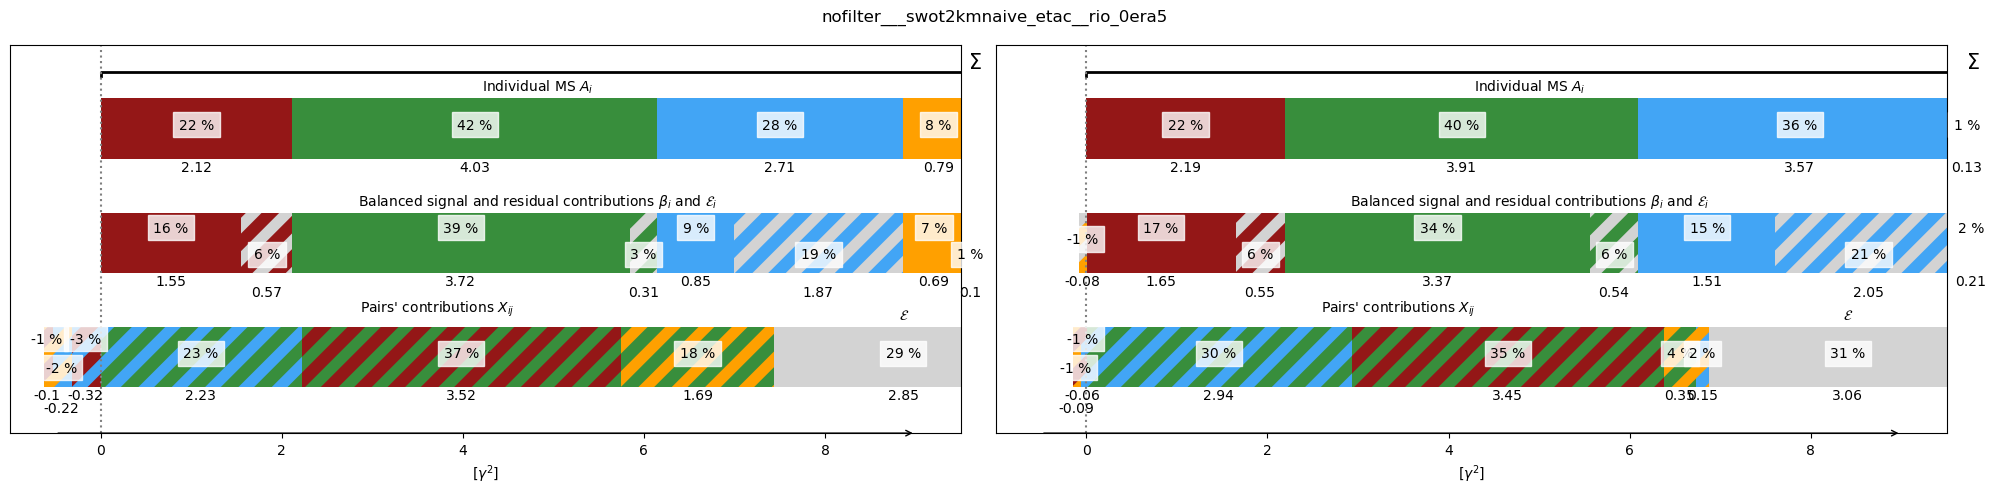

In [5]:
ds = compute_mean_square(DSS, dirname=('e', 'n'))/U2
df = ds.to_dataframe()
print(DSS.sizes['row_number'])
for c in ds.id_comb.values :
    fig, axs = plt.subplots(nrows=1,ncols=2,figsize=(20,5), frameon=False)
    synthetic_figure(df.loc[c], axs[0], dir='e', xlim=[-1, 9])
    synthetic_figure(df.loc[c], axs[1], dir='n', xlim=[-1, 9])
    fig.suptitle(c)
    fig.tight_layout()
    fig.savefig(os.path.join(images_dir, 'closure_figs', c + '_Xy.png'))

25566
9.37722870213147
9.781083968414338
10.06985667428166
10.331499336163537


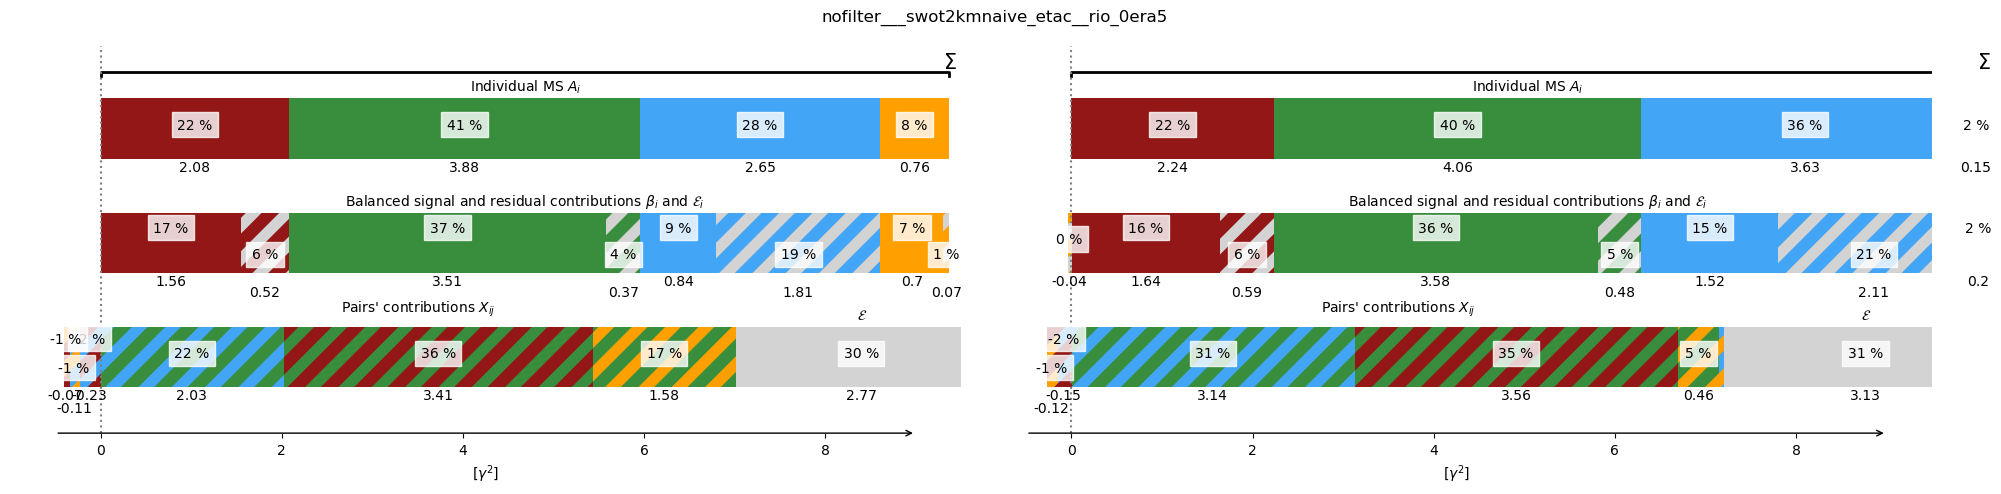

In [6]:
dsr = compute_mean_square(DSSr, dirname=('x', 'y'))/U2
df = dsr.to_dataframe()
print(DSSr.sizes['row_number'])
for c in ds.id_comb.values :
    fig, axs = plt.subplots(nrows=1,ncols=2,figsize=(20,5), frameon=False)
    synthetic_figure(df.loc[c], axs[0], dir='x', xlim=[-1, 9])
    synthetic_figure(df.loc[c], axs[1], dir='y', xlim=[-1, 9])
    fig.suptitle(c)
    fig.tight_layout()
    fig.savefig(os.path.join(images_dir, 'closure_figs', c + '_XY.png'))

_____
# Join pdf Sea-state/cross-track distance

In [7]:
def plot_join_pdfs(ds, x, y, binx=100, biny=100):
    nsamples, yy, xx = np.histogram2d(ds[y], ds[x], bins=(biny, binx))
    da = xr.DataArray(data=nsamples, dims=[y, x],coords={x:([x], (xx[:-1] + xx[1:])/2), y:([y], (yy[:-1] + yy[1:])/2)})
    
    fig = plt.figure(figsize=(9, 4))
    
    # Add a gridspec with two rows and two columns and a ratio of 2 to 7 between
    # the size of the marginal axes and the main axes in both directions.
    # Also adjust the subplot parameters for a square plot.
    gs = fig.add_gridspec(
        2,
        2,
        width_ratios=(7, 2),
        height_ratios=(2, 7),
        left=0.1,
        right=0.9,
        bottom=0.1,
        top=0.9,
        wspace=0.05,
        hspace=0.05,
    )
    
    ax = fig.add_subplot(gs[1, 0])
    ax_histx = fig.add_subplot(gs[0, 0], sharex=ax)
    ax_histy = fig.add_subplot(gs[1, 1], sharey=ax)
    

    
    da.plot(ax=ax, add_colorbar=False)
    #da.plot.contour(ax=ax, add_colorbar=False, colors='orange')
    #ax.plot(xx, -xx, color='r')
    ds[x].plot.hist(bins=binx, density=True, ax=ax_histx, zorder=1)
    ds[y].plot.hist(
        bins=biny,
        density=True,
        ax=ax_histy,
        orientation="horizontal",
        zorder=1,
    )


    # no labels
    ax.grid(zorder=0)
    ax_histx.grid()
    ax_histy.grid()
    ax_histx.tick_params(axis="x", labelbottom=False)
    ax_histy.tick_params(axis="y", labelleft=False)
    ax_histy.set_title('')
    ax_histx.set_title('')
    ax_histy.set_xlabel('')
    ax_histx.set_xlabel('')
    fig.tight_layout(rect=[0, 0, 1, 1])  # left, bottom, right, top (default is 0,0,1,1)

/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_10560/1913541531.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dfs['abs_cross_track_distance'] = abs(dfs['cross_track_distance'])
/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_10560/2910541907.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 1])  # left, bottom, right, top (default is 0,0,1,1)


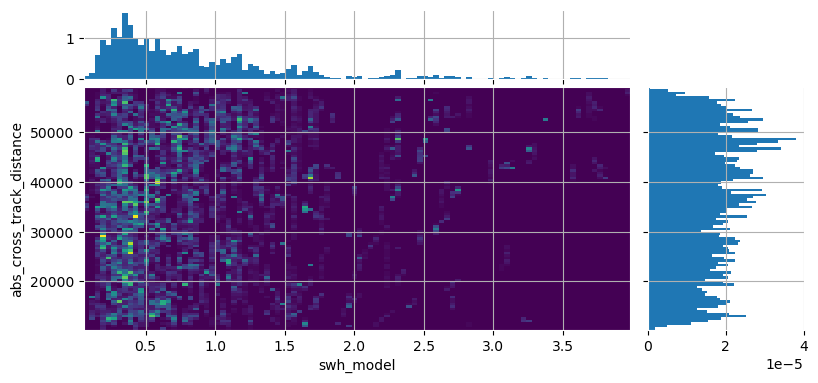

In [8]:
dfr = DSSr.to_dataframe().reset_index().set_index('row_number')
dfs = pd.read_csv(ALTI['swot2kmnaive']).set_index('row_number')
dfs['abs_cross_track_distance'] = abs(dfs['cross_track_distance'])

dfrr = pd.concat([dfs[['swh_model', 'abs_cross_track_distance', 'ssh_karin_uncert', 'distance_to_coast']], dfr], axis=1).dropna()

dss = dfrr.to_xarray()
plot_join_pdfs(dss, 'swh_model', 'abs_cross_track_distance', binx=100, biny=100)

In [9]:
def plot_error(df, x, v, ax, suf='ber'):
    ax.fill_between(
        df[x], df[v] - df[suf+"__" + v], df[v] + df[suf+"__" + v], color="silver"
    )

_________
# Dependency on the cross_track distance

In [14]:
compute_error = 'bootstrap'
dfct = dfrr[dfrr.swh_model<2]
ct_dist_bins = np.arange(0, 70000, 1000)
dfct['abs_cross_track_distance_cut'] = pd.cut(dfct['abs_cross_track_distance'], ct_dist_bins, labels=(ct_dist_bins[1:] + ct_dist_bins[:-1])/2)
dsc = compute_mean_square_groupby(dfct, groupby = 'abs_cross_track_distance_cut', dirname = ('x', 'y'), compute_error=compute_error, vars_errors = ['Ex_ggd', 'Ey_ggd']  )
dsc['meanbin_swh_model'] = dfct.groupby('abs_cross_track_distance_cut', observed=False).swh_model.mean().dropna().to_xarray()
dsc = dsc.where(dsc.nb_coloc>100)
dsc['abs_cross_track_distance_cut'] = dsc['abs_cross_track_distance_cut']/1000

/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_7812/690342853.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfct['abs_cross_track_distance_cut'] = pd.cut(dfct['abs_cross_track_distance'], ct_dist_bins, labels=(ct_dist_bins[1:] + ct_dist_bins[:-1])/2)
/Users/mdemol/code/med_analysis/diagnosis.py:373: UserWarning: `meta` is not specified, inferred from partial data. Please provide `meta` if the result is unexpected.
  Before: .apply(func)
  After:  .apply(func, meta={'x': 'f8', 'y': 'f8'}) for dataframe result
  or:     .apply(func, meta=('x', 'f8'))            for series result
  .apply(compute_bootstrap_error)


Ex_ggd


/Users/mdemol/code/med_analysis/diagnosis.py:373: UserWarning: `meta` is not specified, inferred from partial data. Please provide `meta` if the result is unexpected.
  Before: .apply(func)
  After:  .apply(func, meta={'x': 'f8', 'y': 'f8'}) for dataframe result
  or:     .apply(func, meta=('x', 'f8'))            for series result
  .apply(compute_bootstrap_error)


Ey_ggd


[ 8.84065122e-04 -3.73388222e-02  3.66974928e+00]


(0.0, 7.0)

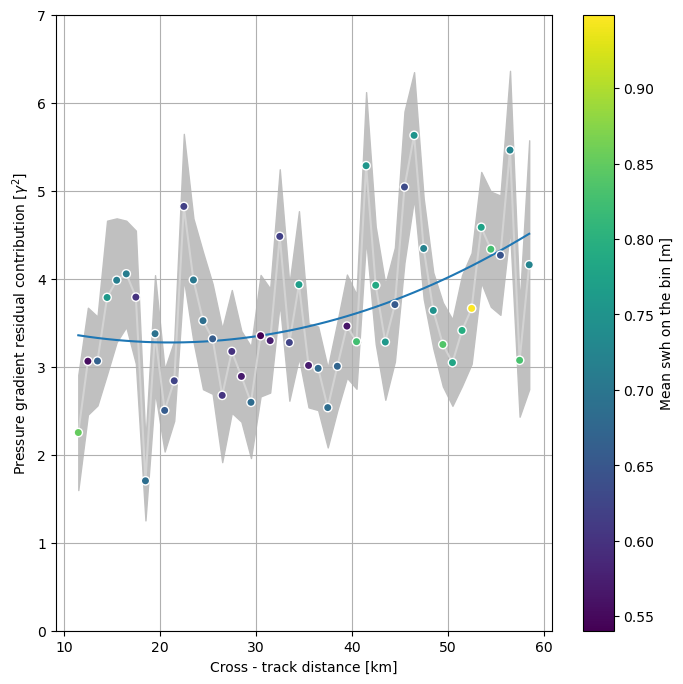

In [51]:
dsc = dsc.dropna('abs_cross_track_distance_cut')

plt.rcParams["axes.edgecolor"] = "k"
fig, ax = plt.subplots(1, 1, figsize=(8,8), frameon=False)
dsc['E_ggd'] = dsc.Ex_ggd + dsc.Ey_ggd
dsc['ber__E_ggd'] = dsc.ber__Ex_ggd + dsc.ber__Ey_ggd
#dsc.Ex_ggd.plot(ax=ax, marker='+')
#dsc.Ey_ggd.plot(ax=ax, marker='+')
dsc.E_ggd.plot(ax=ax, marker='+', c='lightgrey')
plot_error(dsc, 'abs_cross_track_distance_cut', 'E_ggd', ax=ax, suf='ber')
sc = dsc.plot.scatter(x = 'abs_cross_track_distance_cut', y='E_ggd', c=dsc.meanbin_swh_model,zorder=10)
plt.colorbar(sc, label ='Mean swh on the bin [m]')

c = dsc.abs_cross_track_distance_cut
coef = np.polyfit(c, dsc.E_ggd,2,w =dsc.nb_coloc)
ax.plot(c, coef[0]*c**2  +coef[1]*c + coef[2])
print(coef)

ax.grid()
ax.set_ylabel(r'Pressure gradient residual contribution [$\gamma^2$]')
ax.set_xlabel(r'Cross - track distance [km]')
ax.set_ylim(0, 7)

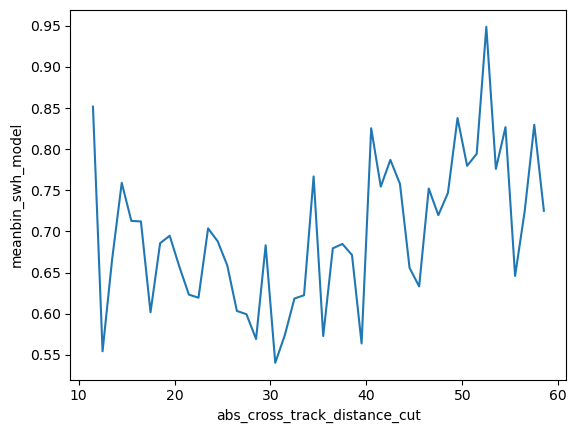

In [19]:
dsc.meanbin_swh_model.plot()

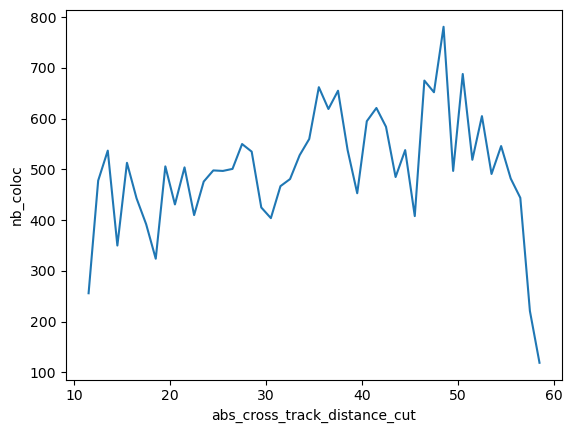

In [20]:
dsc.nb_coloc.plot()

Text(0.5, 0, 'Cross - track distance [km]')

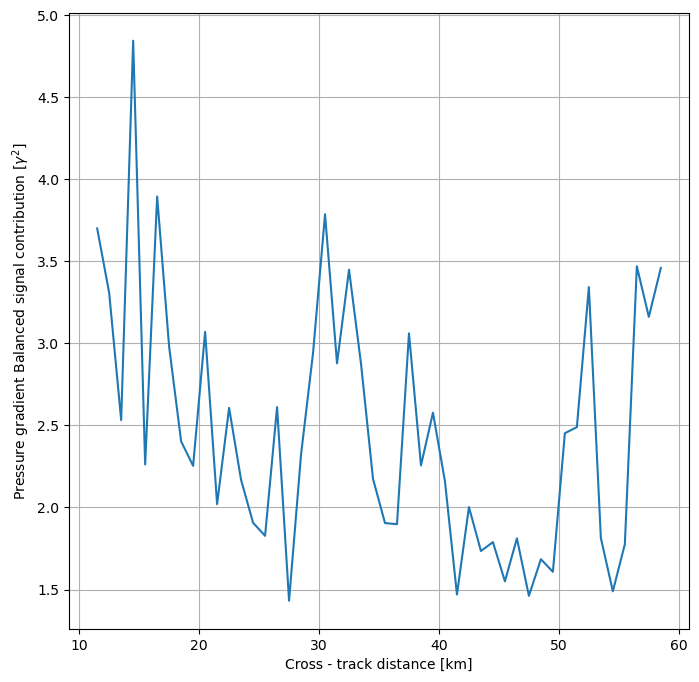

In [21]:
plt.rcParams["axes.edgecolor"] = "k"
fig, ax = plt.subplots(1, 1, figsize=(8,8), frameon=False)
(dsc.Bx_ggd + dsc.By_ggd).plot(ax=ax)
ax.grid()
ax.set_ylabel(r'Pressure gradient Balanced signal contribution [$\gamma^2$]')
ax.set_xlabel(r'Cross - track distance [km]')

In [ ]:
dss = dfrr.to_xarray()
plot_join_pdfs(dss, 'swh_model', 'abs_cross_track_distance', binx=100, biny=100)

_________
# Dependency on the seastate

In [10]:
compute_error = 'bootstrap'

dfswh = dfrr[(dfrr.abs_cross_track_distance>20e3) & (dfrr.abs_cross_track_distance<50e3)]
swh_dist_bins = np.linspace(0, 4.4, 100)
dfswh['swh_model_cut'] = pd.cut(dfswh['swh_model'], swh_dist_bins, labels=(swh_dist_bins[1:] + swh_dist_bins[:-1])/2)
dsswh = compute_mean_square_groupby(dfswh, groupby = 'swh_model_cut', dirname = ('x', 'y'), compute_error =compute_error, vars_errors = ['Ex_ggd', 'Ey_ggd'] )
dsswh['meanbin_abs_cross_track_distance'] = dfswh.groupby('swh_model_cut', observed=False).abs_cross_track_distance.mean().dropna().to_xarray()
dsswh = dsswh.where(dsswh.nb_coloc>0).dropna('swh_model_cut')

/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_10560/1037784249.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfswh['swh_model_cut'] = pd.cut(dfswh['swh_model'], swh_dist_bins, labels=(swh_dist_bins[1:] + swh_dist_bins[:-1])/2)
/Users/mdemol/code/med_analysis/diagnosis.py:373: UserWarning: `meta` is not specified, inferred from partial data. Please provide `meta` if the result is unexpected.
  Before: .apply(func)
  After:  .apply(func, meta={'x': 'f8', 'y': 'f8'}) for dataframe result
  or:     .apply(func, meta=('x', 'f8'))            for series result
  .apply(compute_bootstrap_error)


Ex_ggd


/Users/mdemol/code/med_analysis/diagnosis.py:373: UserWarning: `meta` is not specified, inferred from partial data. Please provide `meta` if the result is unexpected.
  Before: .apply(func)
  After:  .apply(func, meta={'x': 'f8', 'y': 'f8'}) for dataframe result
  or:     .apply(func, meta=('x', 'f8'))            for series result
  .apply(compute_bootstrap_error)


Ey_ggd


In [ ]:
plt.rcParams["axes.edgecolor"] = "k"
fig, ax = plt.subplots(1, 1, figsize=(8,8), frameon=False)
dsswh['E_ggd'] = dsswh.Ex_ggd + dsswh.Ey_ggd
dsswh['ber__E_ggd'] = dsswh.ber__Ex_ggd + dsswh.ber__Ey_ggd
dsswh.E_ggd.plot(ax=ax, marker = 'x', c='lightgrey')
plot_error(dsswh, 'swh_model_cut', 'E_ggd', ax=ax, suf='ber')
sc = dsswh.plot.scatter(x = 'swh_model_cut', y='E_ggd', c=dsswh.meanbin_abs_cross_track_distance,zorder=10)
plt.colorbar(sc, label ='Mean cross track distance on the bin [m]')

c = dsswh.where(dsswh.swh_model_cut<2).swh_model_cut
coef = np.polyfit(c, dsswh.where(dsswh.swh_model_cut<2).E_ggd,2, w =dsswh.where(dsswh.swh_model_cut<2).nb_coloc )
ax.plot(c, coef[0]*c**2  +coef[1]*c + coef[2])


ax.grid()
ax.set_ylabel(r'Pressure gradient residual contribution [$\gamma^2$]')
ax.set_xlabel(r'Sea wave height from model [m]')
ax.set_ylim(0, 50)

Text(0.5, 0, 'Sea wave height from model [m]')

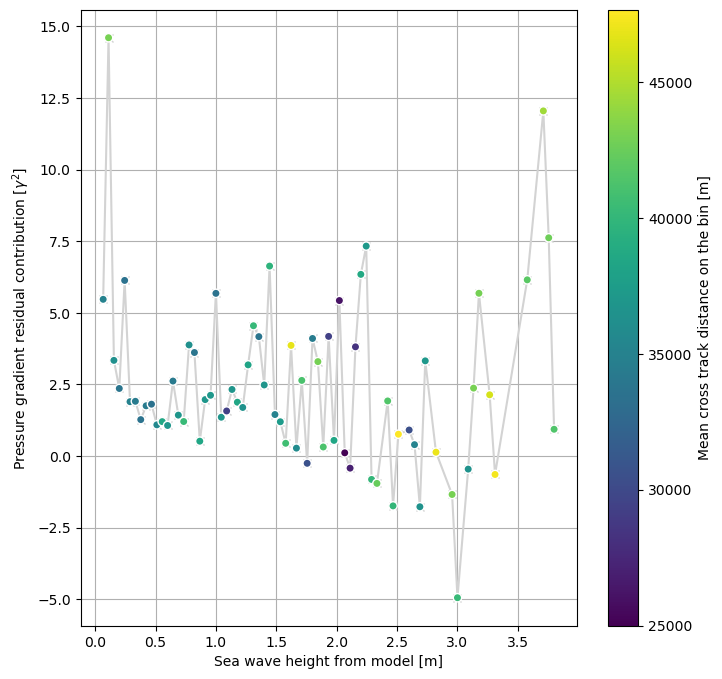

In [56]:
plt.rcParams["axes.edgecolor"] = "k"
fig, ax = plt.subplots(1, 1, figsize=(8,8), frameon=False)
dsswh['B_ggd'] = dsswh.Bx_ggd + dsswh.By_ggd
#dsswh['ber__B_ggd'] = dsswh.ber__Bx_ggd + dsswh.ber__By_ggd
dsswh.B_ggd.plot(ax=ax, marker = 'x', c='lightgrey')
#plot_error(dsswh, 'swh_model_cut', 'E_ggd', ax=ax, suf='ber')
sc = dsswh.plot.scatter(x = 'swh_model_cut', y='B_ggd', c=dsswh.meanbin_abs_cross_track_distance,zorder=10)
plt.colorbar(sc, label ='Mean cross track distance on the bin [m]')



ax.grid()
ax.set_ylabel(r'Pressure gradient residual contribution [$\gamma^2$]')
ax.set_xlabel(r'Sea wave height from model [m]')

/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_7812/235803078.py:8: UserWarning: Adding colorbar to a different Figure <Figure size 800x800 with 5 Axes> than <Figure size 800x800 with 1 Axes> which fig.colorbar is called on.
  plt.colorbar(sc, label ='Mean cross track distance on the bin [m]')


Text(0.5, 0, 'Sea wave height from model [m]')

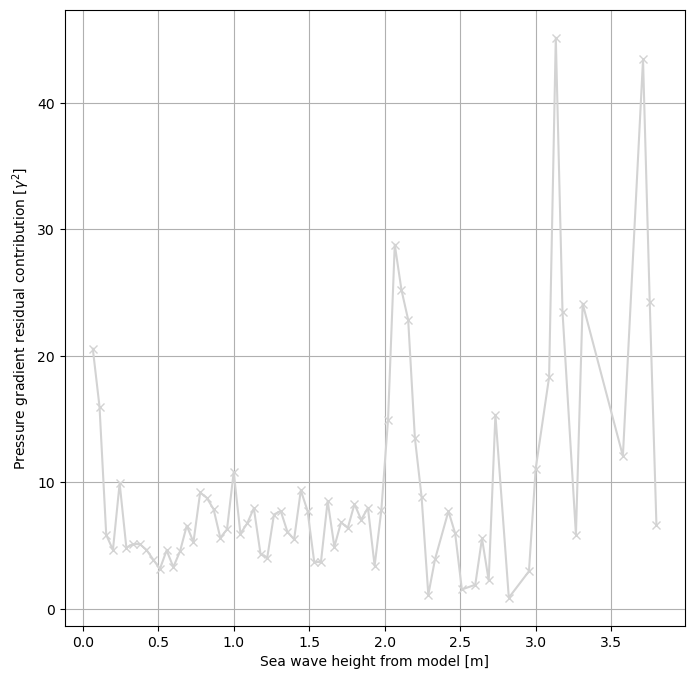

In [78]:
plt.rcParams["axes.edgecolor"] = "k"
fig, ax = plt.subplots(1, 1, figsize=(8,8), frameon=False)
dsswh['B_ggd'] = dsswh.Bx_ggd + dsswh.By_ggd
#dsswh['ber__B_ggd'] = dsswh.ber__Bx_ggd + dsswh.ber__By_ggd
dsswh.GGD.plot(ax=ax, marker = 'x', c='lightgrey')
#plot_error(dsswh, 'swh_model_cut', 'E_ggd', ax=ax, suf='ber')
#sc = dsswh.plot.scatter(x = 'swh_model_cut', y='B_ggd', c=dsswh.meanbin_abs_cross_track_distance,zorder=10)
plt.colorbar(sc, label ='Mean cross track distance on the bin [m]')



ax.grid()
ax.set_ylabel(r'Pressure gradient residual contribution [$\gamma^2$]')
ax.set_xlabel(r'Sea wave height from model [m]')

In [60]:
dfswh['GGD'] = dfswh.ggdx**2  +dfswh.ggdy**2

/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_7812/289193770.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfswh['GGD'] = dfswh.ggdx**2  +dfswh.ggdy**2


/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_7812/3313331956.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dfswh.groupby('swh_model_cut').ggdx.max().plot()
/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_7812/3313331956.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dfswh.groupby('swh_model_cut').ggdy.max().plot()


<Axes: xlabel='swh_model_cut'>

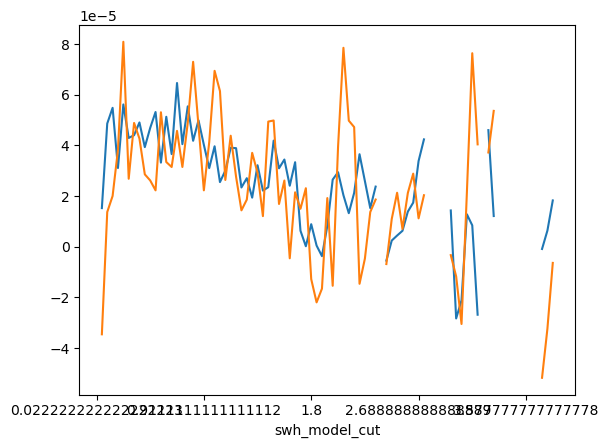

In [70]:
dfswh.groupby('swh_model_cut').ggdx.max().plot()
dfswh.groupby('swh_model_cut').ggdy.max().plot()

/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_7812/3313331956.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dfswh.groupby('swh_model_cut').ggdx.max().plot()
/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_7812/3313331956.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dfswh.groupby('swh_model_cut').ggdy.max().plot()


<Axes: xlabel='swh_model_cut'>

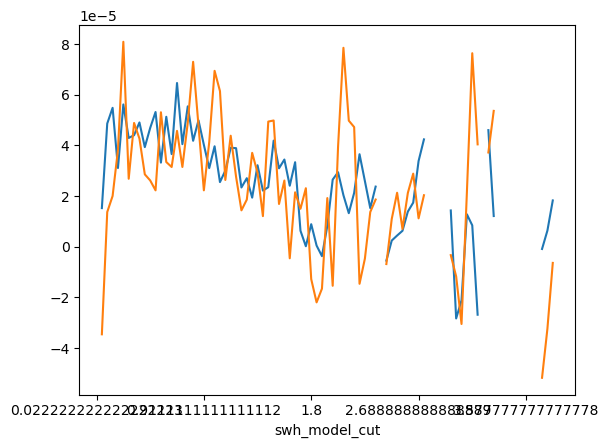

In [70]:
dfswh.groupby('swh_model_cut').ggdx.max().plot()
dfswh.groupby('swh_model_cut').ggdy.max().plot()

/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_7812/44657078.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  (dfswh.groupby('swh_model_cut').GGD.max()/U2).plot()
/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_7812/44657078.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  (dfswh.groupby('swh_model_cut').GGD.mean()/U2).plot()
/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_7812/44657078.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=Tru

<Axes: xlabel='swh_model_cut'>

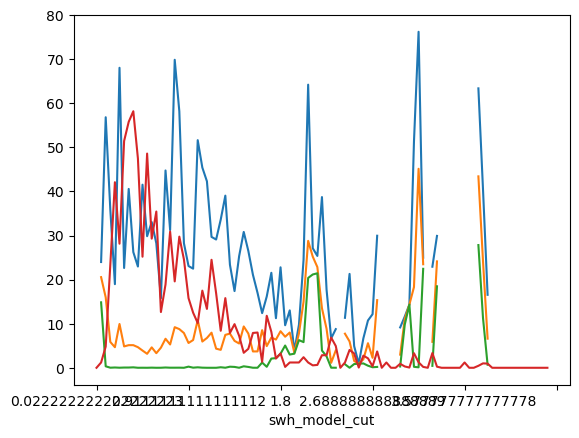

In [86]:
(dfswh.groupby('swh_model_cut').GGD.max()/U2).plot()
(dfswh.groupby('swh_model_cut').GGD.mean()/U2).plot()
(dfswh.groupby('swh_model_cut').GGD.min()/U2).plot()
(dfswh.groupby('swh_model_cut').GGD.count()/20).plot()

/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_7812/3852017604.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dfswh.groupby('swh_model_cut').GGD.count().plot()


<Axes: xlabel='swh_model_cut'>

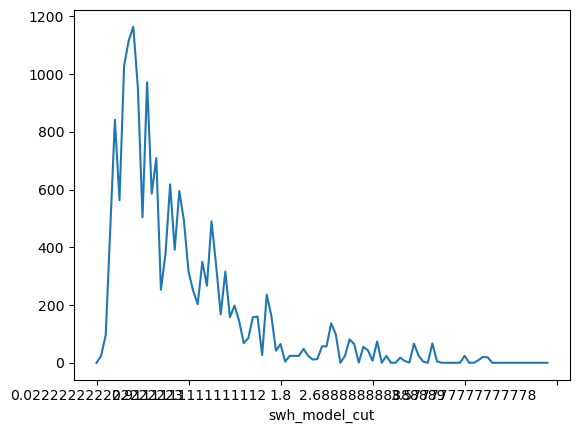

In [85]:
dfswh.groupby('swh_model_cut').GGD.count().plot()

/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_7812/2910541907.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 1])  # left, bottom, right, top (default is 0,0,1,1)


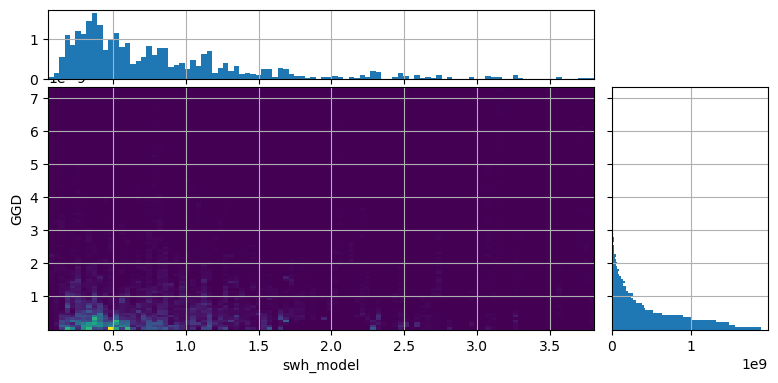

In [61]:
dss = dfswh.to_xarray()
plot_join_pdfs(dss, 'swh_model', 'GGD', binx=100, biny=100)

_________
# Dependency on the ssh_karin_uncert

In [36]:
compute_error = 'centrallimit'

dfsu = dfrr
su_dist_bins = np.linspace(0.001, 0.004, 100)
dfsu['su_cut'] = pd.cut(dfsu['ssh_karin_uncert'], su_dist_bins, labels=(su_dist_bins[1:] + su_dist_bins[:-1])/2)
dssu = compute_mean_square_groupby(dfsu, groupby = 'su_cut', dirname = ('x', 'y'), compute_error = compute_error, vars_errors = ['Ex_ggd', 'Ey_ggd'] )
#dssu['meanbin_abs_cross_track_distance'] = dfsu.groupby('su_model_cut', observed=False).abs_cross_track_distance.mean().dropna().to_xarray()
dssu = dssu.where(dssu.nb_coloc>0)#.dropna()

In [ ]:
dssu.Ex_ggd.plot()

In [ ]:
plt.rcParams["axes.edgecolor"] = "k"
dssu.Ex_ggd.plot()

In [ ]:
dssu.nb_coloc.plot()

________
# Distance_to_coast

In [40]:
compute_error = 'bootstrap'

dfdtc = dfrr.copy()
dtc_bins = np.linspace(0, 200e3, 100)
dfdtc['dtc_cut'] = pd.cut(dfdtc['distance_to_coast'], dtc_bins, labels=(dtc_bins[1:] + dtc_bins[:-1])/2)
dsdtc = compute_mean_square_groupby(dfdtc, groupby = 'dtc_cut', dirname = ('x', 'y'), compute_error =compute_error, vars_errors = ['Ex_ggd', 'Ey_ggd'] )
dsdtc = dsdtc.where(dsdtc.nb_coloc>0).dropna('dtc_cut')

/Users/mdemol/code/med_analysis/diagnosis.py:373: UserWarning: `meta` is not specified, inferred from partial data. Please provide `meta` if the result is unexpected.
  Before: .apply(func)
  After:  .apply(func, meta={'x': 'f8', 'y': 'f8'}) for dataframe result
  or:     .apply(func, meta=('x', 'f8'))            for series result
  .apply(compute_bootstrap_error)


Ex_ggd


/Users/mdemol/code/med_analysis/diagnosis.py:373: UserWarning: `meta` is not specified, inferred from partial data. Please provide `meta` if the result is unexpected.
  Before: .apply(func)
  After:  .apply(func, meta={'x': 'f8', 'y': 'f8'}) for dataframe result
  or:     .apply(func, meta=('x', 'f8'))            for series result
  .apply(compute_bootstrap_error)


Ey_ggd


Text(0.5, 0, 'Distance to coast [m]')

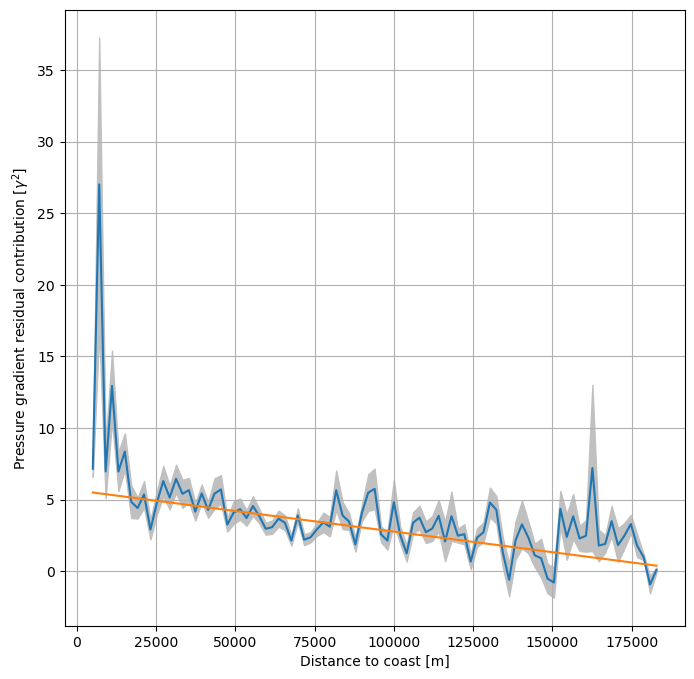

In [49]:
plt.rcParams["axes.edgecolor"] = "k"
fig, ax = plt.subplots(1, 1, figsize=(8,8), frameon=False)
#dsdtc.Ex_ggd.plot(ax=ax, label='x')
#dsdtc.Ey_ggd.plot(ax=ax, label='y')
dsdtc.E_ggd.plot(ax=ax, label='')
dsdtc['ber__E_ggd'] = dsdtc.ber__Ex_ggd + dsdtc.ber__Ey_ggd
plot_error(dsdtc, 'dtc_cut', 'E_ggd', ax=ax, suf='ber')

c = dsdtc.dtc_cut
coef = np.polyfit(c, dsdtc.E_ggd, 1, w =dsdtc.nb_coloc)
ax.plot(c, coef[0]*c  +coef[1])

ax.grid()
ax.set_ylabel(r'Pressure gradient residual contribution [$\gamma^2$]')
ax.set_xlabel(r'Distance to coast [m]')